# VPS-Net Training

**Paper:** Vacant Parking Slot Detection in the Around View Image Based on Deep Learning (Sensors 2020)

**Paper Link:** https://www.mdpi.com/1424-8220/20/7/2138

**GitHub:** https://github.com/weili1457355863/VPS-Net

---

## Section 3.4: Occupancy Classification

> "the parking slot is cut and warped to a uniform size with 120 x 46 pixels according to its position in the image. The perspective transform technique is used to implement this warping process."

> "We perform a **180 rotation transformation** to further increase the number of training samples."

## Section 4.1.2: Training Settings

> "In the implementation process, the customized DCNN model used pre-trained on the ImageNet, and then is fine-tuned in our training samples, including 12,772 positive samples and 5066 negative samples. **The choices of optimizer, the learning rate setting and the data augmentation are the same as when the YOLOv3-based detector is trained.**"

## Section 3.1: YOLOv3 Training

> "**Data augmentation** is performed during the training process. We **flip the image** and the corresponding bounding box with a **50% probability level**. We also add **color augmentations with a 50% chance**, including random **saturation with [1.0, 1.5]**, and random **exposure with [1.0, 1.5]** in the **HSV color space**."

## Complete Augmentation Pipeline

1. **180 rotation** (Section 3.4)
2. **Horizontal flip 50%** (Section 3.1, via "same as YOLOv3")
3. **HSV color jitter 50%**: saturation [1.0, 1.5], exposure [1.0, 1.5] (Section 3.1, via "same as YOLOv3")

## Training Hyperparameters

- Optimizer: Adam [b1=0.9, b2=0.999, eps=10^-8]
- LR: 0.0001, decayed by 10 every 45,000 gradient steps
- Batch size: 32
- Input: 120x46 RGB (perspective-warped parking slot)
- Output: 2 classes (vacant=0, non-vacant=1)

In [1]:
!pip install -q gdown seaborn scikit-learn scipy

In [2]:
# Core imports
import os
import sys
import glob
import time
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!git clone https://github.com/weili1457355863/VPS-Net.git /kaggle/working/VPS-Net

Cloning into '/kaggle/working/VPS-Net'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 66 (delta 17), reused 60 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 5.61 MiB | 48.30 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [ ]:
import gdown
import zipfile
import os
import glob

# ps2.0 dataset
print('Downloading ps2.0 dataset...')
gdown.download(id='1i1pSnkIRyTgt6kmWr_sN6jrasX2HngWc', output='/kaggle/working/ps2.0.zip', quiet=False)
with zipfile.ZipFile('/kaggle/working/ps2.0.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/data')
print('ps2.0 extracted.')

# VPS-Net annotations
print('Downloading VPS-Net annotations...')
gdown.download(id='1IQxiXrfdIxfpHaTWyXGHQCvZUSRMTGSK', output='/kaggle/working/annotations.zip', quiet=False)
with zipfile.ZipFile('/kaggle/working/annotations.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/annotations')
print('Outer zip extracted.')

# Extract ALL nested zips
for root, dirs, files in os.walk('/kaggle/working/annotations'):
    for f in files:
        if f.endswith('.zip'):
            zip_path = os.path.join(root, f)
            extract_to = os.path.join('/kaggle/working/VPS-Net/data')
            print(f'Extracting nested: {zip_path}')
            with zipfile.ZipFile(zip_path, 'r') as zr:
                zr.extractall(extract_to)

# Also extract directly from annotation_vps
for nested_zip in glob.glob('/kaggle/working/annotations/**/*.zip', recursive=True):
    extract_to = '/kaggle/working/VPS-Net/data'
    print(f'Ensuring extraction: {nested_zip}')
    with zipfile.ZipFile(nested_zip, 'r') as zr:
        zr.extractall(extract_to)

# Verify: annotations are .mat files
vpsnet_mats = glob.glob('/kaggle/working/VPS-Net/data/**/*.mat', recursive=True)
print(f'VPS-Net annotation .mat files found: {len(vpsnet_mats)}')
vpsnet_train_mats = glob.glob('/kaggle/working/VPS-Net/data/ps2.0/training_vps/*.mat')
print(f'  training_vps: {len(vpsnet_train_mats)} .mat files')
vpsnet_test_mats = glob.glob('/kaggle/working/VPS-Net/data/ps2.0/testing_vps/**/*.mat', recursive=True)
print(f'  testing_vps:  {len(vpsnet_test_mats)} .mat files')

# Check ps2.0 images
ps20_jpgs = glob.glob('/kaggle/working/data/training/*.jpg')
print(f'\nps2.0 training images: {len(ps20_jpgs)}')
if vpsnet_train_mats:
    print(f'Sample annotation: {vpsnet_train_mats[0]}')

Downloading...
From (original): https://drive.google.com/uc?id=1i1pSnkIRyTgt6kmWr_sN6jrasX2HngWc
From (redirected): https://drive.google.com/uc?id=1i1pSnkIRyTgt6kmWr_sN6jrasX2HngWc&confirm=t&uuid=c9e9a005-ec13-44e1-8949-980d52521db4
To: /kaggle/working/ps2.0.zip
100%|██████████| 2.40G/2.40G [00:19<00:00, 121MB/s] 


ps2.0 extracted.


Downloading...
From (original): https://drive.google.com/uc?id=1IQxiXrfdIxfpHaTWyXGHQCvZUSRMTGSK
From (redirected): https://drive.google.com/uc?id=1IQxiXrfdIxfpHaTWyXGHQCvZUSRMTGSK&confirm=t&uuid=3f3f8d7c-3e9b-46e6-8c01-56abe28f1263
To: /kaggle/working/annotations.zip
100%|██████████| 5.97M/5.97M [00:00<00:00, 32.6MB/s]


Outer zip extracted.
Extracting nested: /kaggle/working/annotations/annotation_vps/psv.zip
Extracting nested: /kaggle/working/annotations/annotation_vps/ps2.0.zip
Ensuring extraction: /kaggle/working/annotations/annotation_vps/psv.zip
Ensuring extraction: /kaggle/working/annotations/annotation_vps/ps2.0.zip
VPS-Net annotation .mat files found: 15754
  training_vps: 9827 .mat files
  testing_vps:  4653 .mat files

ps2.0 training images: 9827
Sample annotation: /kaggle/working/VPS-Net/data/ps2.0/training_vps/p2_img115_1188.mat


In [5]:
# ps2.0 images are in data/training/ and data/testing/
# VPS-Net annotations (with occupancy labels) are .mat files in VPS-Net/data/ps2.0/

ps20_train = '/kaggle/working/data/training'
ps20_test = '/kaggle/working/data/testing'

train_jpgs = sorted([f for f in os.listdir(ps20_train) if f.endswith('.jpg')])
print(f'ps2.0 train images: {len(train_jpgs)} in {ps20_train}')

# VPS-Net annotations: .mat files with same stem as images
vpsnet_train_anno = '/kaggle/working/VPS-Net/data/ps2.0/training_vps'
vpsnet_test_anno = '/kaggle/working/VPS-Net/data/ps2.0/testing_vps'

train_mats = sorted([f for f in os.listdir(vpsnet_train_anno) if f.endswith('.mat')])
print(f'VPS-Net train annotations: {len(train_mats)} in {vpsnet_train_anno}')

# Check matching between images and annotations
train_img_stems = set(os.path.splitext(f)[0] for f in train_jpgs)
train_anno_stems = set(os.path.splitext(f)[0] for f in train_mats)
matched = train_img_stems & train_anno_stems
only_imgs = train_img_stems - train_anno_stems
only_annos = train_anno_stems - train_img_stems
print(f'\nMatched: {len(matched)}')
print(f'Images without annotation: {len(only_imgs)}')
print(f'Annotations without image: {len(only_annos)}')

if only_imgs:
    print(f'  Unmatched images sample: {list(only_imgs)[:3]}')
if only_annos:
    print(f'  Unmatched annotations sample: {list(only_annos)[:3]}')

# Inspect one .mat file to verify format
import scipy.io as sio
sample_mat = os.path.join(vpsnet_train_anno, train_mats[0])
print(f'Inspecting: {sample_mat}')
mat_data = sio.loadmat(sample_mat, squeeze_me=True)
for k, v in mat_data.items():
    if not k.startswith('__'):
        print(f'  {k}: type={type(v).__name__}, shape={getattr(v, "shape", "N/A")}, dtype={getattr(v, "dtype", "N/A")}')
        if hasattr(v, 'dtype') and v.dtype.names:
            print(f'    fields: {v.dtype.names}')
            for name in v.dtype.names:
                fv = v[name]
                print(f'    {name}: shape={getattr(fv, "shape", "N/A")}, dtype={getattr(fv, "dtype", "N/A")}')
                if hasattr(fv, 'flat') and len(fv.flat) > 0:
                    print(f'      sample: {fv.flat[0]}')
        elif hasattr(v, 'flat') and len(v.flat) > 0:
            print(f'    first element: {v.flat[0]}')

ps2.0 train images: 9827 in /kaggle/working/data/training
VPS-Net train annotations: 9827 in /kaggle/working/VPS-Net/data/ps2.0/training_vps

Matched: 9827
Images without annotation: 0
Annotations without image: 0
Inspecting: /kaggle/working/VPS-Net/data/ps2.0/training_vps/20160725-3-1.mat
  marks: type=ndarray, shape=(3, 2), dtype=float64
    first element: 240.47823834196888
  slots: type=ndarray, shape=(2, 4), dtype=uint8
    first element: 3


In [ ]:
# Import CustomizedAlexNet directly from repo (models/Customized.py)
# Repo class inherits BasicModule which adds load()/save() helpers
sys.path.insert(0, '/kaggle/working/VPS-Net')
from utils.utils import compute_four_points, fixed_ROI, crop_margin
from models.Customized import CustomizedAlexNet

import torchvision.models as models

def load_imagenet_weights(model):
    """4.1.2: load AlexNet pretrained ImageNet weights into CustomizedAlexNet.

    Architecture diff (AlexNet -> Customized):
      Conv1: (64,3,11,11) -> (40,3,3,9)   -- channel + spatial mismatch
      Conv2: (192,64,5,5) -> (80,40,3,5)
      Conv3: (384,192,3,3) -> (120,80,3,3) -- spatial match
      Conv4: (256,384,3,3) -> (160,120,3,3)

    Strategy: L2-norm channel selection (keep most active pretrained features)
    + spatial center-crop for kernel size mismatch.
    """
    alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

    # Conv layer index pairs: (alexnet_feat_idx, custom_feat_idx)
    for a_idx, c_idx in [(0, 0), (3, 3), (6, 6), (8, 8)]:
        aw = alexnet.features[a_idx].weight.data  # (out_a, in_a, kh_a, kw_a)
        cw = model.features[c_idx].weight.data     # (out_c, in_c, kh_c, kw_c)

        # Select output channels by L2 norm -- keeps most "active" pretrained features
        out_l2 = aw.view(aw.shape[0], -1).pow(2).sum(dim=1)
        _, top_out = out_l2.topk(cw.shape[0])
        top_out = top_out.sort()[0]  # preserve original channel ordering

        # Select input channels by L2 norm across selected outputs
        in_l2 = aw[top_out].permute(1, 0, 2, 3).reshape(aw.shape[1], -1).pow(2).sum(dim=1)
        _, top_in = in_l2.topk(cw.shape[1])
        top_in = top_in.sort()[0]

        # Center-crop spatial dims (kernel size mismatch in conv1/conv2)
        sh = (aw.shape[2] - cw.shape[2]) // 2
        sw = (aw.shape[3] - cw.shape[3]) // 2

        cw.data = aw[top_out][:, top_in, sh:sh+cw.shape[2], sw:sw+cw.shape[3]].to(cw.device)
        if model.features[c_idx].bias is not None:
            model.features[c_idx].bias.data = alexnet.features[a_idx].bias.data[top_out].to(cw.device)

    # FC1: L2-norm channel selection on both output and input dims
    af = alexnet.classifier[1].weight.data  # (4096, 9216)
    cf = model.classifier[1].weight.data     # (512, 4000)
    out_l2 = af.pow(2).sum(dim=1)
    _, top_out = out_l2.topk(cf.shape[0])
    top_out = top_out.sort()[0]
    in_l2 = af[top_out].pow(2).sum(dim=0)
    _, top_in = in_l2.topk(cf.shape[1])
    top_in = top_in.sort()[0]
    cf.data = af[top_out][:, top_in].to(cf.device)
    model.classifier[1].bias.data = alexnet.classifier[1].bias.data[top_out].to(cf.device)

    print('Loaded ImageNet pretrained weights (L2-norm channel selection)')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"}')

# Patch repo: suppress debug print from compute_four_points
import utils.utils as _utils
import io, contextlib
_orig_cfp = _utils.compute_four_points
def _quiet_cfp(*args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()):
        return _orig_cfp(*args, **kwargs)
_utils.compute_four_points = _quiet_cfp
compute_four_points = _quiet_cfp

Device: cuda
GPU: Tesla T4


In [ ]:
# Import preprocessing directly from repo (vps_detect/vps_classify.py)
# vpsClassify.image_preprocess: crop_margin -> fixed_ROI -> perspective warp -> resize
from vps_detect.vps_classify import vpsClassify

class _TrainPreprocess(vpsClassify):
    """Inherit image_preprocess from repo, skip __init__ (no model loading)."""
    def __init__(self):
        pass  # no model loading

_preprocessor = _TrainPreprocess()
regularize_parking_slot = _preprocessor.image_preprocess

In [ ]:
# ============================================================
# From readme.txt (VPS-Net annotation):
#   data.marks = Nx2 array of [x, y] marking point coordinates
#   data.slots = Mx4 array: [pt1_index, pt2_index, label, angle]
#     MATLAB 1-indexed
#     label (col3 in readme = col2 in 0-indexed Python):
#       0 = vacant
#       1 = non-vacant (occupied)
#       2 = vehicle in parking slot
#     angle: parking angle (90 for ps2.0)
# ============================================================

import scipy.io as sio

def parse_vpsnet_mat(mat_path):
    """Parse .mat annotation file. Returns list of (angle, pt1, pt2, label).

    MATLAB format (confirmed via readme.txt):
      data.marks: Nx2 [x,y] marking point coordinates
      data.slots: Mx4 [pt1_idx, pt2_idx, label, angle] -- 1-indexed
      label: 0=vacant, 1=non-vacant, 2=vehicle-in-slot
    """
    try:
        raw = sio.loadmat(mat_path, squeeze_me=False)
    except Exception:
        return []
    slots = []
    
    marks = raw.get('marks', None)
    slot_data = raw.get('slots', None)
    
    if marks is None or slot_data is None:
        return []
    
    marks = np.asarray(marks, dtype=np.float64)
    slot_data = np.asarray(slot_data)
    
    if marks.size == 0 or slot_data.size == 0:
        return []
    
    if marks.ndim == 1:
        marks = marks.reshape(-1, 2)
    elif marks.ndim == 3:
        marks = marks.reshape(-1, 2)
    elif marks.ndim == 2 and marks.shape[1] != 2:
        marks = marks.reshape(-1, 2)
    
    if slot_data.dtype == object:
        rows = []
        for item in slot_data.flat:
            arr = np.asarray(item, dtype=np.float64).flatten()
            if len(arr) >= 4:
                rows.append(arr[:4])
        slot_data = np.array(rows) if rows else np.empty((0, 0))
    elif slot_data.ndim >= 2:
        slot_data = slot_data.reshape(-1, slot_data.shape[-1])
    elif slot_data.ndim == 1 and slot_data.size >= 4:
        slot_data = slot_data.reshape(1, -1)
    else:
        return []
    
    if slot_data.size == 0 or marks.ndim != 2:
        return []
    
    for row in slot_data:
        try:
            pt1_idx = int(row[0]) - 1
            pt2_idx = int(row[1]) - 1
            label = int(row[2])
            angle = float(row[3])
            if pt1_idx < 0 or pt1_idx >= len(marks) or pt2_idx < 0 or pt2_idx >= len(marks):
                continue
            if label not in (0, 1, 2):
                continue
            pt1 = marks[pt1_idx].copy()
            pt2 = marks[pt2_idx].copy()
            slots.append((angle, pt1, pt2, label))
        except Exception:
            continue
    
    return slots

def generate_pseudo_label(img, pts):
    """Fallback: compute occupancy from average brightness in warped slot.
    Used only when .mat annotation is missing or empty.
    """
    try:
        crop = regularize_parking_slot(img, pts)
        if crop is None:
            return -1
        gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
        mean_val = float(gray.mean())
        std_val = float(gray.std())
        if std_val > 25 and mean_val < 160:
            return 1
        return 0
    except Exception:
        return -1

# Test with first annotation
test_mat = os.path.join(vpsnet_train_anno, train_mats[0])
test_slots = parse_vpsnet_mat(test_mat)
print(f'Parsed {len(test_slots)} slots from {train_mats[0]}')
if test_slots:
    for i, (a, p1, p2, lbl) in enumerate(test_slots):
        lbl_name = {0: 'vacant', 1: 'non-vacant', 2: 'vehicle-in-slot'}.get(lbl, f'unknown({lbl})')
        print(f'  slot[{i}]: angle={a}, pt1={p1}, pt2={p2}, label={lbl} ({lbl_name})')


Parsed 2 slots from 20160725-3-1.mat
  slot[0]: angle=90.0, pt1=[235.33316062 227.5611399 ], pt2=[240.47823834  57.81295337], label=1 (non-vacant)
  slot[1]: angle=90.0, pt1=[226.80673575 388.58290155], pt2=[235.33316062 227.5611399 ], label=0 (vacant)


In [ ]:
# ============================================================
# Custom Dataset: loads ps2.0 .mat annotations, warps parking slots to 120x46
# Label handling: 0=vacant, 1=non-vacant, 2=vehicle-in-slot
# Train: skip label=2 (paper excludes from counts)
# Test: map label=2 -> 1 (paper counts as non-vacant)
# ============================================================

class VPSNetDataset(Dataset):
    def __init__(self, img_dir, vpsnet_anno_dir, transform=None, augment=False, is_train=True):
        self.img_dir = img_dir
        self.vpsnet_anno_dir = vpsnet_anno_dir
        self.transform = transform
        self.augment = augment
        self.samples = []
        
        # Build index of all .mat files
        mat_index = {}
        for root, dirs, files in os.walk(vpsnet_anno_dir):
            for f in files:
                if f.endswith('.mat'):
                    mat_index[os.path.splitext(f)[0]] = os.path.join(root, f)
        print(f'  Annotation index: {len(mat_index)} .mat files')
        
        img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
        
        for fname in img_files:
            img_path = os.path.join(img_dir, fname)
            stem = os.path.splitext(fname)[0]
            if stem not in mat_index:
                continue
            mat_path = mat_index[stem]
            
            vpsnet_slots = parse_vpsnet_mat(mat_path)
            if not vpsnet_slots:
                continue
            
            for angle, pt1, pt2, label in vpsnet_slots:
                # Paper: exclude label=2 from training, map to non-vacant in test
                if label == 2:
                    if is_train:
                        continue
                    else:
                        label = 1
                self.samples.append({
                    'img_path': img_path,
                    'angle': angle,
                    'pt1': pt1,
                    'pt2': pt2,
                    'label': label
                })
        
        labels = [s['label'] for s in self.samples]
        vacant = labels.count(0)
        non_vacant = labels.count(1)
        print(f'Loaded {len(self.samples)} samples (Vacant: {vacant}, Non-vacant: {non_vacant})')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = cv2.imread(sample['img_path'])
        if img is None:
            img = np.zeros((600, 600, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pts = compute_four_points(sample['angle'], sample['pt1'], sample['pt2'])
        regul_img = regularize_parking_slot(img, pts)
        if regul_img is None:
            regul_img = np.zeros((46, 120, 3), dtype=np.uint8)
        label = sample['label']
        
        if self.augment:
            if np.random.random() < 0.5:
                regul_img = cv2.rotate(regul_img, cv2.ROTATE_180)
        
        if self.transform:
            regul_img = self.transform(regul_img)
        
        return regul_img, label


In [ ]:
# ============================================================
# Complete data augmentation pipeline
# 3.4: 180 rotation (handled in Dataset.__getitem__)
# 3.1 (via 4.1.2 "same as YOLOv3"):
#   - Horizontal flip 50%
#   - HSV color jitter 50%: saturation [1.0, 1.5], exposure [1.0, 1.5]
# ============================================================

class PaperAugmentation:
    """3.4 augmentation: horizontal flip + HSV color jitter.
    Note: 180-deg rotation is handled separately in Dataset.__getitem__.
    """
    def __init__(self, p_hflip=0.5, p_color=0.5):
        self.p_hflip = p_hflip
        self.p_color = p_color
    
    def __call__(self, img):
        # Horizontal flip with p=0.5
        if np.random.random() < self.p_hflip:
            img = cv2.flip(img, 1)
        if np.random.random() < self.p_color:
            img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
            sat_factor = 1.0 + np.random.random() * 0.5
            img_hsv[:, :, 1] = np.clip(img_hsv[:, :, 1] * sat_factor, 0, 255)  # saturation
            exp_factor = 1.0 + np.random.random() * 0.5
            img_hsv[:, :, 2] = np.clip(img_hsv[:, :, 2] * exp_factor, 0, 255)  # exposure/value
            img = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        return img


train_transform = transforms.Compose([
    PaperAugmentation(p_hflip=0.5, p_color=0.5),
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets using discovered paths
# Training: flat directory with .jpg images
# Testing: subdirectories (outdoor-slanted, outdoor-shadow, etc.)

train_dataset = VPSNetDataset(
    img_dir=ps20_train,
    vpsnet_anno_dir=vpsnet_train_anno,
    transform=train_transform,
    augment=True
)

# For testing, collect images from all subdirectories
test_img_dir = '/kaggle/working/data/testing/all'
if not os.path.exists(test_img_dir):
    # Fallback: use first subdirectory with images
    for sub in sorted(os.listdir(ps20_test)):
        sub_path = os.path.join(ps20_test, sub)
        if os.path.isdir(sub_path) and any(f.endswith('.jpg') for f in os.listdir(sub_path)):
            test_img_dir = sub_path
            break

print(f'Test image dir: {test_img_dir}')
val_dataset = VPSNetDataset(
    img_dir=test_img_dir,
    vpsnet_anno_dir=vpsnet_test_anno,
    transform=val_transform,
    augment=False,
    is_train=False
)

paper_train = 8948  # 17,838 / 2 (180 rot counted in paper)
paper_test = 2145  # ps2.0 test = 2145 (1596 vacant + 549 non-vacant)
our_train = len(train_dataset)
our_test = len(val_dataset)
sep = '=' * 50
print(f'\nDataset Comparison (paper vs ours)')
print(sep)
print(f'  Train (pre-rot / x2 rot):')
print(f'    Paper: {paper_train} / {paper_train*2}')
print(f'    Ours:  {our_train} / {our_train*2}')
print(f'    Diff:  {our_train-paper_train:+d} / {our_train*2-paper_train*2:+d}')
print(f'  Test:')
print(f'    Paper: {paper_test} (1596V + 549NV)')
print(f'    Ours:  {our_test} (V + NV including label=2 mapped)')
print(f'    Diff:  {our_test-paper_test:+d}')
print('=' * 50)
match_train = 'MATCH' if abs(our_train - paper_train) / paper_train < 0.05 else 'MISMATCH'
match_test = 'MATCH' if abs(our_test - paper_test) / paper_test < 0.05 else 'MISMATCH'
print(f'Train: {match_train} | Test: {match_test}')

if len(train_dataset) == 0:
    raise ValueError('ERROR: 0 training samples! Check .mat annotation format.')
if len(val_dataset) == 0:
    print('WARNING: 0 val samples — will skip validation during training.')

  Annotation index: 9827 .mat files
Loaded 8948 samples (Vacant: 6324, Non-vacant: 2624)
Test image dir: /kaggle/working/data/testing/all
  Annotation index: 2928 .mat files
Loaded 2173 samples (Vacant: 1599, Non-vacant: 574)

Dataset Comparison (paper vs ours)
  Train (pre-rot / x2 rot):
    Paper: 8948 / 17896
    Ours:  8948 / 17896
    Diff:  +0 / +0
  Test:
    Paper: 2145 (1596V + 549NV)
    Ours:  2173 (V + NV including label=2 mapped)
    Diff:  +28
Train: MATCH | Test: MATCH


In [12]:
# Paper: batch size = 32
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2) if len(val_dataset) > 0 else None

print(f'Train batches/epoch: {len(train_loader)}')
print(f'Val batches: {len(val_loader) if val_loader else 0}')

Train batches/epoch: 279
Val batches: 68


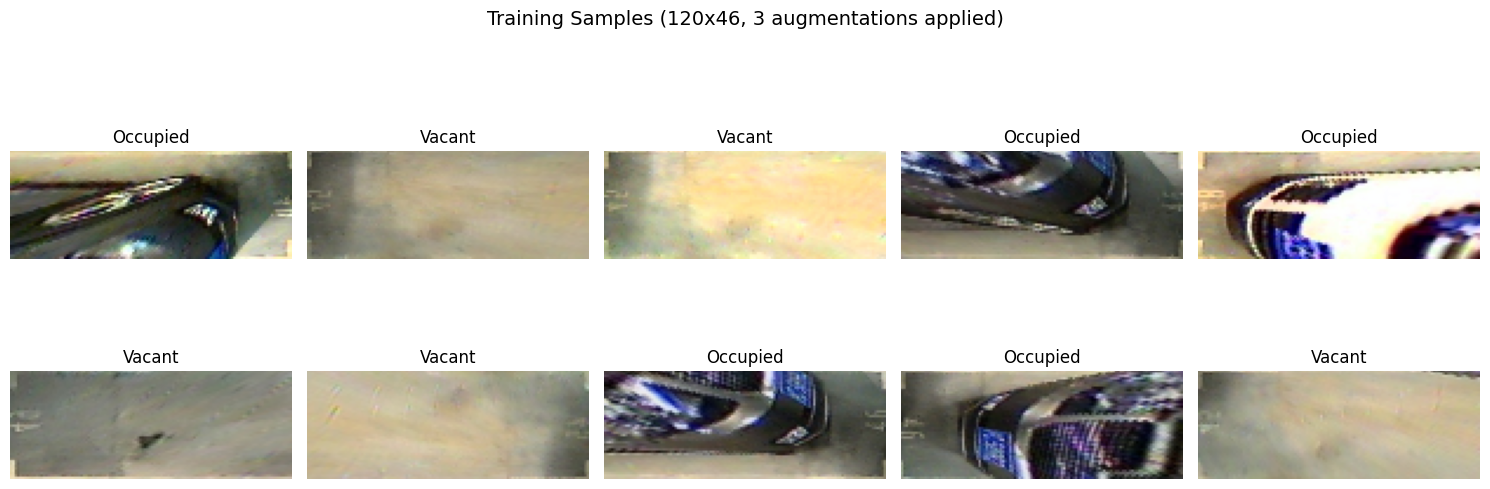

In [13]:
# Visualize augmented samples
n_show = min(10, len(train_dataset))
if n_show > 0:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(n_show):
        img, label = train_dataset[i]
        ax = axes[i // 5, i % 5]
        img_np = img.numpy().transpose(1, 2, 0)
        img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        ax.set_title(f'{"Vacant" if label == 0 else "Occupied"}')
        ax.axis('off')
    plt.suptitle('Training Samples (120x46, 3 augmentations applied)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No training samples to visualize.')

In [ ]:
# ============================================================
# CustomizedAlexNet (explicit definition above)
# Verified against paper Table 1 and repo models/Customized.py
# ============================================================

model = CustomizedAlexNet(num_classes=2).to(device)
load_imagenet_weights(model)  # Paper: pre-train on ImageNet first
criterion = nn.CrossEntropyLoss()

# 4.1.2: Adam [b1=0.9, b2=0.999, eps=1e-8], LR=0.0001
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, betas=(0.9, 0.999), eps=1e-8)

# LR decayed by 10 every 45,000 GRADIENT STEPS
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=45000, gamma=0.1)


total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total:,} total, {trainable:,} trainable')

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 241MB/s] 


Loaded ImageNet pretrained weights (L2-norm channel selection)
Model parameters: 2,360,378 total, 2,360,378 trainable


In [ ]:
# ============================================================
# Training loop
# LR decayed by 10 every 45,000 GRADIENT STEPS (not epochs)
# scheduler.step() called inside batch loop after each optimizer.step()
# ============================================================

EPOCHS = 323  # 279 batches * 323 = 90,117 steps -> 2 LR decays at 45k and 90k
best_acc = 0.0
global_step = 0
os.makedirs('/kaggle/working/VPS-Net/weights', exist_ok=True)

train_losses = []
val_accs = []
train_accs = []
lr_history = []

for epoch in range(EPOCHS):
    model.train()
    correct = total = 0
    epoch_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # LR decayed by 10 every 45,000 steps
        global_step += 1
        scheduler.step()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        epoch_loss += loss.item()
        pbar.set_postfix({'lr': f'{optimizer.param_groups[0]["lr"]:.8f}', 'step': global_step})
    
    train_acc = 100. * correct / total
    epoch_loss /= len(train_loader)
    
    model.eval()
    correct = total = 0
    with torch.no_grad():
        if val_loader:
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
    val_acc = 100. * correct / total if total > 0 else 0.0
    
    train_losses.append(epoch_loss)
    val_accs.append(val_acc)
    train_accs.append(train_acc)
    lr_history.append(optimizer.param_groups[0]['lr'])
    
    print(f'Loss: {epoch_loss:.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | LR: {optimizer.param_groups[0]["lr"]:.8f} | Step: {global_step}')
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), '/kaggle/working/VPS-Net/weights/Customized.pth')
        print(f'>>> Saved best: {val_acc:.2f}%')

print(f'\nBest: {best_acc:.2f}% | Paper target: 99.48% | Steps: {global_step}')

Epoch 1/323: 100%|██████████| 279/279 [00:44<00:00,  6.26it/s, lr=0.00010000, step=279]


Loss: 0.1672 | Train: 94.52% | Val: 97.24% | LR: 0.00010000 | Step: 279
>>> Saved best: 97.24%


Epoch 2/323: 100%|██████████| 279/279 [00:43<00:00,  6.43it/s, lr=0.00010000, step=558]


Loss: 0.1049 | Train: 97.09% | Val: 97.70% | LR: 0.00010000 | Step: 558
>>> Saved best: 97.70%


Epoch 3/323: 100%|██████████| 279/279 [00:42<00:00,  6.51it/s, lr=0.00010000, step=837]


...

Loss: 0.0001 | Train: 100.00% | Val: 98.11% | LR: 0.00001000 | Step: 89559


Epoch 322/323: 100%|██████████| 279/279 [00:45<00:00,  6.08it/s, lr=0.00001000, step=89838]


Loss: 0.0000 | Train: 100.00% | Val: 98.07% | LR: 0.00001000 | Step: 89838


Epoch 323/323: 100%|██████████| 279/279 [00:45<00:00,  6.13it/s, lr=0.00000100, step=90117]


Loss: 0.0001 | Train: 100.00% | Val: 98.07% | LR: 0.00000100 | Step: 90117

Best: 98.53% | Paper target: 99.48% | Steps: 90117


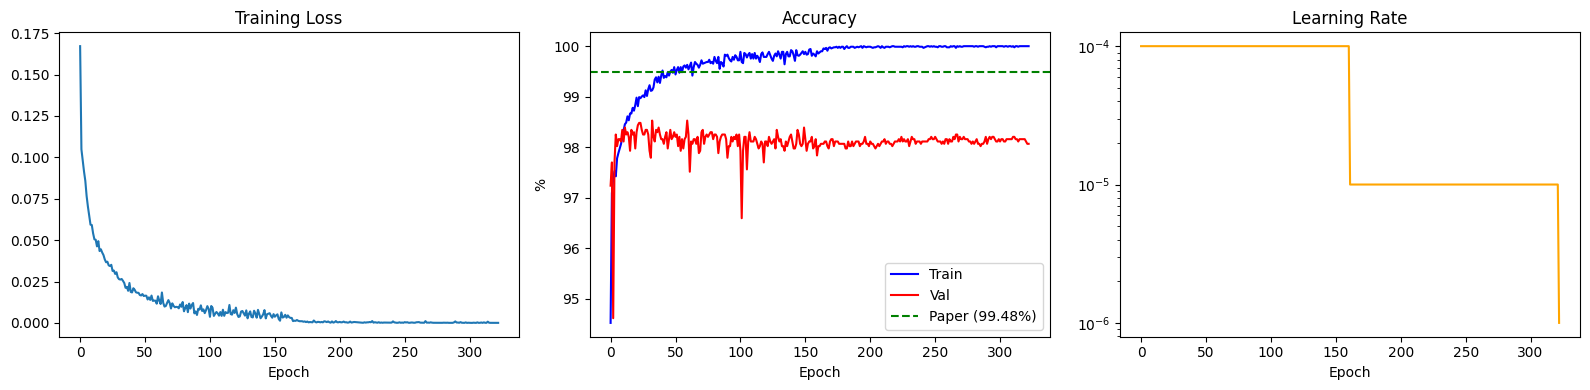

In [16]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(train_losses)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(train_accs, label='Train', color='blue')
axes[1].plot(val_accs, label='Val', color='red')
axes[1].axhline(y=99.48, color='green', linestyle='--', label='Paper (99.48%)')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()
axes[2].plot(lr_history, color='orange')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
plt.tight_layout()
plt.savefig('/kaggle/working/VPS-Net/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

              precision    recall  f1-score   support

      Vacant       0.99      0.99      0.99      1599
  Non-vacant       0.96      0.98      0.97       574

    accuracy                           0.99      2173
   macro avg       0.98      0.98      0.98      2173
weighted avg       0.99      0.99      0.99      2173



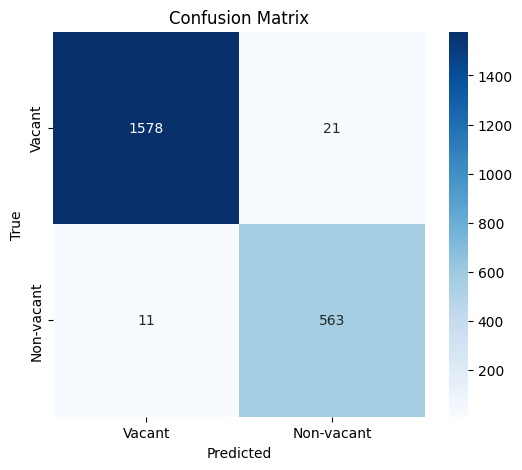


Table 7: Occupancy Classification Performance
Model                          Accuracy   Time(ms)   Size(MB)
----------------------------------------------------------------------
  HOG+SVM [37]                   92.54%       2.13       0.04
  AlexNet [49]                   99.67%       1.75      228.1
  VGG-16 [50]                    99.62%       2.15      537.1
  ResNet-50 [51]                 98.55%       5.10       44.8
  MobileNetV3-Small [52]         98.55%       6.21        5.1
  Customized DCNN (paper)        99.48%       0.81        9.4
----------------------------------------------------------------------
  Customized DCNN (Ours)         98.53%      0.60      9.01


In [ ]:
# ============================================================
# Accuracy + Speed (ms) + Model Size (MB)
# Customized DCNN = 99.48%, 0.81ms, 9.4MB
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

if val_loader:
    model.load_state_dict(torch.load('/kaggle/working/VPS-Net/weights/Customized.pth', map_location=device, weights_only=True))
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds, target_names=['Vacant', 'Non-vacant']))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Vacant', 'Non-vacant'], yticklabels=['Vacant', 'Non-vacant'])
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.savefig('/kaggle/working/VPS-Net/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Speed: inference time per image (ms)
    dummy = torch.randn(1, 3, 46, 120).to(device)
    for _ in range(10):
        with torch.no_grad(): _ = model(dummy)
        if device.type == "cuda": torch.cuda.synchronize()
    times = []
    for _ in range(100):
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad(): _ = model(dummy)
        if device.type == "cuda": torch.cuda.synchronize()
        times.append((time.time() - t0) * 1000)
    avg_ms = sum(times) / len(times)

    # Model size (MB)
    import os
    model_size_mb = os.path.getsize('/kaggle/working/VPS-Net/weights/Customized.pth') / (1024*1024)

    accuracy = cm.diagonal().sum() / cm.sum() * 100
    print()
    print('=' * 70)
    print('Table 7: Occupancy Classification Performance')
    print('=' * 70)
    hdr = "{:<28s} {:>10s} {:>10s} {:>10s}".format("Model", "Accuracy", "Time(ms)", "Size(MB)")
    print(hdr)
    print('-' * 70)
    rows = [
        ("HOG+SVM [37]", "92.54%", "2.13", "0.04"),
        ("AlexNet [49]", "99.67%", "1.75", "228.1"),
        ("VGG-16 [50]", "99.62%", "2.15", "537.1"),
        ("ResNet-50 [51]", "98.55%", "5.10", "44.8"),
        ("MobileNetV3-Small [52]", "98.55%", "6.21", "5.1"),
        ("Customized DCNN (paper)", "99.48%", "0.81", "9.4"),
    ]
    for name, acc, spd, sz in rows:
        print("  {:<26s} {:>10s} {:>10s} {:>10s}".format(name, acc, spd, sz))
    print('-' * 70)
    print("  {:<26s} {:>9.2f}% {:>9.2f} {:>9.2f}".format("Customized DCNN (Ours)", accuracy, avg_ms, model_size_mb))
    print('=' * 70)
else:
    print('No validation data.')

In [18]:
# Save training log
import csv
with open('/kaggle/working/VPS-Net/training_log.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'train_acc', 'val_acc', 'lr', 'global_step'])
    for i in range(len(train_losses)):
        writer.writerow([i+1, f'{train_losses[i]:.6f}', f'{train_accs[i]:.2f}', f'{val_accs[i]:.2f}', f'{lr_history[i]:.10f}', global_step])

print('Log: /kaggle/working/VPS-Net/training_log.csv')
print('Best weights: /kaggle/working/VPS-Net/weights/Customized.pth')

Log: /kaggle/working/VPS-Net/training_log.csv
Best weights: /kaggle/working/VPS-Net/weights/Customized.pth
